## Imports

In [17]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

## Create State Schema

In [2]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float

    equation: str
    discriminant: float
    roots: str

## Create functions for graph nodes

In [ ]:
def show_equation(state: QuadState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {"equation": equation}

def discriminant(state: QuadState):
    discriminant = state['b']**2 -4*state['a']*state['c']
    return {'discriminant':discriminant}

def no_real_roots(state:QuadState):
    return {'roots': f"No real roots since discriminant is {state['discriminant']}"}

def real_roots(state:QuadState):
    r1 = (-state['b']+state['discriminant']**0.5)/(2*state['a'])
    r2 = (-state['b']-state['discriminant']**0.5)/(2*state['a'])
    return {'roots': f"Roots are {round(r1,4)} and {round(r2,4)}"}

def repeated_roots(state:QuadState):
    r1 = (-state['b'])/(2*state['a'])
    return {'roots': f"Only repeating root is {round(r1,4)}"}

def check_discriminant(state: QuadState)-> Literal["no_real_roots","real_roots","repeated_roots"]:
    # Note the function returns the name of edges not the name of functions
    if state['discriminant']>0:
        return "real_roots"
    elif state['discriminant']==0:
        return "repeated_roots"
    else:
        return "no_real_roots"

## Build Graph object

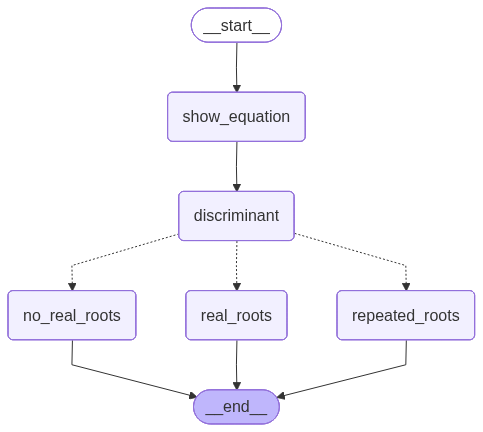

In [19]:
graph = StateGraph(QuadState)

# add nodes
graph.add_node("show_equation", show_equation)
graph.add_node("discriminant", discriminant)
graph.add_node("no_real_roots", no_real_roots)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)

# add edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'discriminant')

graph.add_conditional_edges("discriminant",check_discriminant)
graph.add_edge("no_real_roots",END)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)

# compile
workflow = graph.compile()

# visualize
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [23]:
initial_state = {'a':1,
                 'b':6,
                 'c':6}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': 6, 'c': 6, 'equation': '1x^2 + 6x + 6', 'discriminant': 12, 'roots': 'Roots are -1.2679 and -4.7321'}
